<a href="https://colab.research.google.com/github/brenoazvd/FIAP---DATA-SCIENCE/blob/main/07_10_2024_deep_learning_ia_previs%C3%B5es.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Previsão de Preços de Ações com Redes Neurais Recorrentes (LSTM)

#Breno Azevedo

Epoch 1/150


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.0395 - mean_absolute_error: 0.1420
Epoch 2/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - loss: 0.0101 - mean_absolute_error: 0.0747
Epoch 3/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0084 - mean_absolute_error: 0.0684
Epoch 4/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - loss: 0.0060 - mean_absolute_error: 0.0564
Epoch 5/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - loss: 0.0081 - mean_absolute_error: 0.0655
Epoch 6/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0054 - mean_absolute_error: 0.0545
Epoch 7/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - loss: 0.0054 - mean_absolute_error: 0.0536
Epoch 8/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0048 - mean_absolute_error: 0.0492
Epoch 9/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - loss: 0.0049 - mean_absolute_error: 0.0505
Epoch 10/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - loss: 0.0034 - mean_absolute_error: 0.0415
Epoch 11/150
37/37 ━━━━━━━━━━━━━━━━━━━

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step
Média previsões: R$27.12
Média real: R$27.62
MAE: R$0.61
RMSE: R$0.74


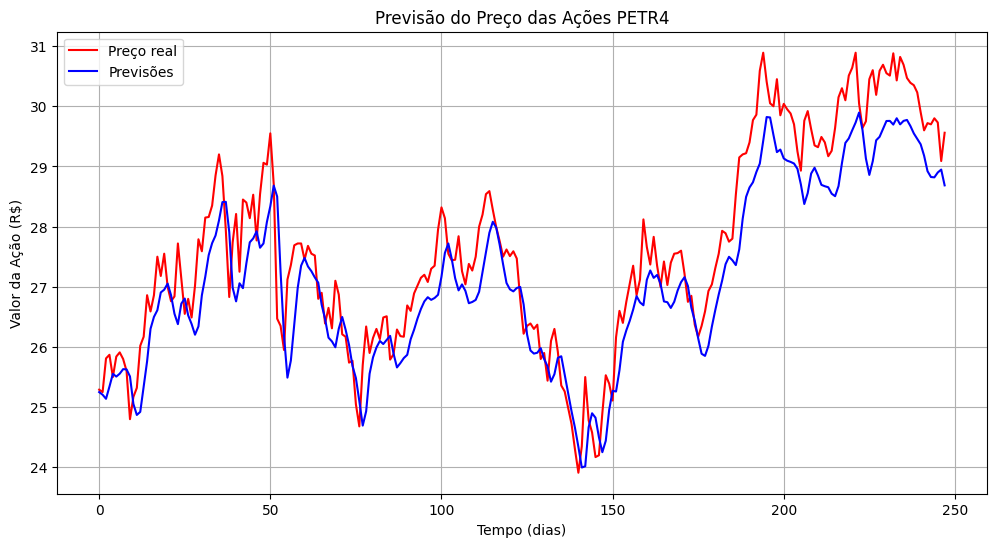

In [41]:
# Instalação de pacotes (se necessário)
!pip install keras scikit-learn

# Imports
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Carregando a base de dados
base = pd.read_csv('/home/PETR4.csv')
base = base.dropna()

base_treinamento = base.iloc[:, 1:2].values  # Coluna "Open"

# Normalizando os dados
normalizador = MinMaxScaler(feature_range=(0,1))
base_treinamento_normalizada = normalizador.fit_transform(base_treinamento)

# Criando sequências de entrada e saída
previsores = []
preco_real = []

for i in range(90, len(base_treinamento_normalizada)):
    previsores.append(base_treinamento_normalizada[i-90:i, 0])
    preco_real.append(base_treinamento_normalizada[i, 0])

previsores, preco_real = np.array(previsores), np.array(preco_real)
previsores = np.reshape(previsores, (previsores.shape[0], previsores.shape[1], 1))

# Criando a Rede Neural Recorrente (LSTM)
regressor = Sequential()

regressor.add(LSTM(units=100, return_sequences=True, input_shape=(previsores.shape[1], 1)))
regressor.add(Dropout(0.3))

regressor.add(LSTM(units=50, return_sequences=False))  # Corrigido aqui
regressor.add(Dropout(0.3))

regressor.add(Dense(units=25, activation='relu'))
regressor.add(Dense(units=1, activation='linear'))

regressor.compile(optimizer='rmsprop', loss='mean_squared_error', metrics=['mean_absolute_error'])

# Treinamento
regressor.fit(previsores, preco_real, epochs=150, batch_size=32)

# Preparação da base de teste
base_teste = pd.read_csv('/home/PETR4_teste.csv')
preco_real_teste = base_teste.iloc[:, 1:2].values  # coluna "Open"

base_completa = pd.concat((base['Open'], base_teste['Open']), axis=0)
inicio = len(base_completa) - len(base_teste) - 90
entradas = base_completa[inicio:].values.reshape(-1, 1)
entradas = normalizador.transform(entradas)

# Criando os dados de entrada do teste
X_teste = []
for i in range(90, 90 + len(base_teste)):
    X_teste.append(entradas[i-90:i, 0])
X_teste = np.array(X_teste)
X_teste = np.reshape(X_teste, (X_teste.shape[0], X_teste.shape[1], 1))

# Previsões
previsoes = regressor.predict(X_teste)
previsoes = normalizador.inverse_transform(previsoes)

# Avaliação
mae = mean_absolute_error(preco_real_teste, previsoes)
rmse = mean_squared_error(preco_real_teste, previsoes) ** 0.5  # Corrigido aqui

print("Média previsões: R${:.2f}".format(previsoes.mean()))
print("Média real: R${:.2f}".format(preco_real_teste.mean()))
print("MAE: R${:.2f}".format(mae))
print("RMSE: R${:.2f}".format(rmse))


# Plotando os resultados
plt.figure(figsize=(12,6))
plt.plot(preco_real_teste, color='red', label='Preço real')
plt.plot(previsoes, color='blue', label='Previsões')
plt.title('Previsão do Preço das Ações PETR4')
plt.xlabel('Tempo (dias)')
plt.ylabel('Valor da Ação (R$)')
plt.legend()
plt.grid(True)
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━

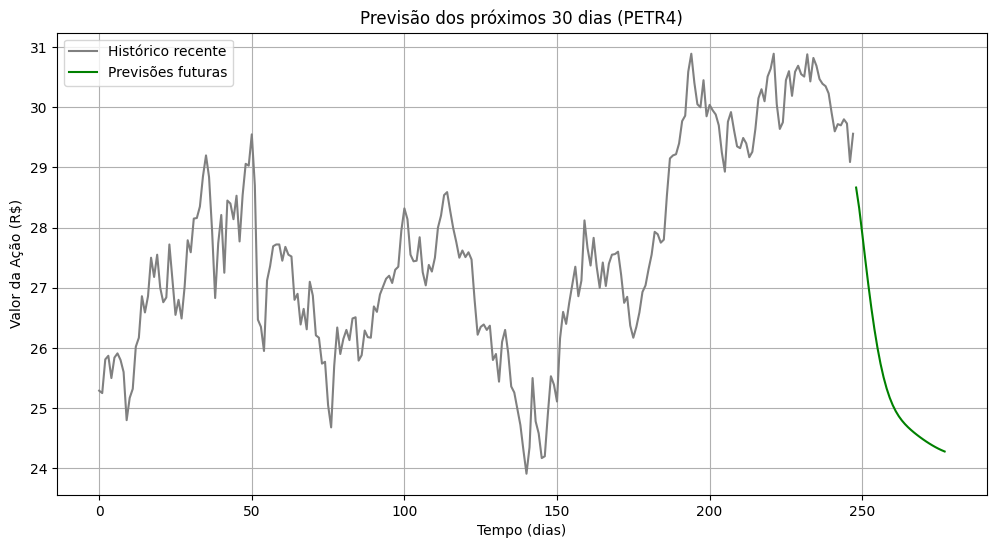

In [44]:
# Use os últimos 90 dias REAIS do total (treino + teste)
base_completa = pd.concat((base['Open'], base_teste['Open']), axis=0)
entrada_futura = base_completa[-90:].values.reshape(-1, 1)
entrada_futura_norm = normalizador.transform(entrada_futura)

# Previsão
sequencia = list(entrada_futura_norm.flatten())
previsoes_futuras = []

for _ in range(30):
    X_input = np.array(sequencia[-90:]).reshape((1, 90, 1))
    nova_previsao = regressor.predict(X_input)[0][0]
    previsoes_futuras.append(nova_previsao)
    sequencia.append(nova_previsao)

# Desnormaliza
previsoes_futuras = np.array(previsoes_futuras).reshape(-1, 1)
previsoes_futuras_desnorm = normalizador.inverse_transform(previsoes_futuras)

# Plota com continuidade correta
plt.figure(figsize=(12,6))
plt.plot(base_completa[-len(preco_real_teste):].values, label='Histórico recente', color='gray')
plt.plot(range(len(preco_real_teste), len(preco_real_teste) + 30), previsoes_futuras_desnorm, color='green', label='Previsões futuras')
plt.title('Previsão dos próximos 30 dias (PETR4)')
plt.xlabel('Tempo (dias)')
plt.ylabel('Valor da Ação (R$)')
plt.legend()
plt.grid(True)
plt.show()


In [45]:
# Verifique as 5 primeiras e últimas linhas dos dados
import pandas as pd

base = pd.read_csv('/home/PETR4.csv')
base_teste = pd.read_csv('/home/PETR4_teste.csv')

print("Dados de treino:")
print(base.head())      # Início
print(base.tail())      # Fim

print("\nDados de teste:")
print(base_teste.head())
print(base_teste.tail())

Dados de treino:
         Date   Open   High    Low  Close  Adj Close    Volume
0  2014-01-27  15.21  15.29  15.04  15.11   7.136948  20818700
1  2014-01-28  15.36  15.44  15.02  15.05   7.108608  22373700
2  2014-01-29  15.06  15.14  14.70  14.80   6.990527  25561100
3  2014-01-30  14.88  15.10  14.63  14.70   6.943292  25607800
4  2014-01-31  14.64  15.07  14.55  14.70   6.943292  49314200
            Date       Open       High        Low      Close  Adj Close  \
1238  2019-01-18  25.440001  25.559999  25.280001  25.400000  13.345062   
1239  2019-01-21  25.309999  25.530001  25.100000  25.530001  13.413365   
1240  2019-01-22  25.260000  25.500000  25.020000  25.129999  13.203205   
1241  2019-01-23  25.330000  25.540001  25.160000  25.430000  13.360826   
1242  2019-01-24  25.400000  25.540001  25.320000  25.540001  13.418618   

        Volume  
1238  67021300  
1239  45336500  
1240  61307000  
1241  52931600  
1242  40109000  

Dados de teste:
         Date       Open       High

In [ ]:
!pip install keras

In [ ]:
!pip install scikit-learn

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
!pip install yfinance


In [ ]:
base = pd.read_csv('/home/PETR4.csv')

base = base.dropna()

base_treinamento = base.iloc[:, 1:2].values

base_treinamento

normalizador = MinMaxScaler(feature_range=(0,1))
base_treinamento_normalizada = normalizador.fit_transform(base_treinamento)

base_treinamento_normalizada

previsores = []
preco_real = []
for i in range(90, len(base_treinamento_normalizada)):
    previsores.append(base_treinamento_normalizada[i-90:i, 0])
    preco_real.append(base_treinamento_normalizada[i, 0])



In [ ]:
previsores

preco_real

[np.float64(0.555694098088113),
 np.float64(0.5752286367414795),
 np.float64(0.6026600581878636),
 np.float64(0.5997505818786367),
 np.float64(0.6151288445552784),
 np.float64(0.6005818786367413),
 np.float64(0.5906068162926017),
 np.float64(0.6005818786367413),
 np.float64(0.6047381546134662),
 np.float64(0.5856193266832916),
 np.float64(0.5403159185369908),
 np.float64(0.5515377805486283),
 np.float64(0.5423940149625934),
 np.float64(0.5469659600997505),
 np.float64(0.5465502909393183),
 np.float64(0.5399002909393182),
 np.float64(0.5278470490440563),
 np.float64(0.5498753117206981),
 np.float64(0.5490440565253532),
 np.float64(0.5469659600997505),
 np.float64(0.5644223192019948),
 np.float64(0.5764754779717373),
 np.float64(0.5935162094763091),
 np.float64(0.6192851205320032),
 np.float64(0.6296758104738154),
 np.float64(0.6234414380714879),
 np.float64(0.6903573981712385),
 np.float64(0.6745635910224438),
 np.float64(0.6940980881130505),
 np.float64(0.6799667082294264),
 np.float64

In [ ]:
previsores, preco_real = np.array(previsores), np.array(preco_real)

In [ ]:
previsores = np.reshape(previsores,(previsores.shape[0], previsores.shape[1], 1))

previsores.shape[1]

90

In [ ]:
#Criando a rede neuralo recorrente
regressor = Sequential()

regressor.add(LSTM(units = 100, return_sequences = True, input_shape = (previsores.shape[1], 1)))
regressor.add(Dropout(0.3))

regressor.add(LSTM(units = 50, return_sequences = True))
regressor.add(Dropout(0.3))

regressor.add(Dense(units = 1, activation = 'linear'))

regressor.compile(optimizer = 'rmsprop', loss = 'mean_squared_error',
                  metrics = ['mean_absolute_error'])

regressor.fit(previsores, preco_real, epochs = 100, batch_size = 32)

base_teste = pd.read_csv('/home/PETR4_teste.csv')
preco_real_teste = base_teste.iloc[:, 1:2].values

print(preco_real_teste)

base_completa = pd.concat((base['Open'], base_teste['Open']), axis = 0)

print("Base treinamento: {}\nBase teste: {}\nBase completa: {}".format(
    len(base_treinamento), len(base_teste), len(base_completa))
)

inicio = len(base_completa) - len(base_teste) - 90
print(inicio)

entradas = base_completa[inicio: ].values

entradas = entradas.reshape(-1, 1)

entradas = normalizador.transform(entradas)

X_teste = []
final = 90 +len(base_teste)
for i in range(90, final):
    X_teste.append(entradas[i-90:i, 0])
X_teste = np.array(X_teste)
X_teste = np.reshape(X_teste, (X_teste.shape[0], X_teste.shape[1], 1))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 17s 286ms/step - loss: 0.1062 - mean_absolute_error: 0.2581
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 13s 90ms/step - loss: 0.0618 - mean_absolute_error: 0.1997
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - loss: 0.0592 - mean_absolute_error: 0.1955
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - loss: 0.0551 - mean_absolute_error: 0.1908
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0514 - mean_absolute_error: 0.1819
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - loss: 0.0517 - mean_absolute_error: 0.1827
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - loss: 0.0547 - mean_absolute_error: 0.1891
Epoch 8/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0526 - mean_absolute_error: 0.1850
Epoch 9/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - loss: 0.0523 - mean_absolute_error: 0.1845
Epoch 10/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - loss: 0.0528 - mean_absolute_error: 0.1869
Epoch 11/100
37/37 ━━━━

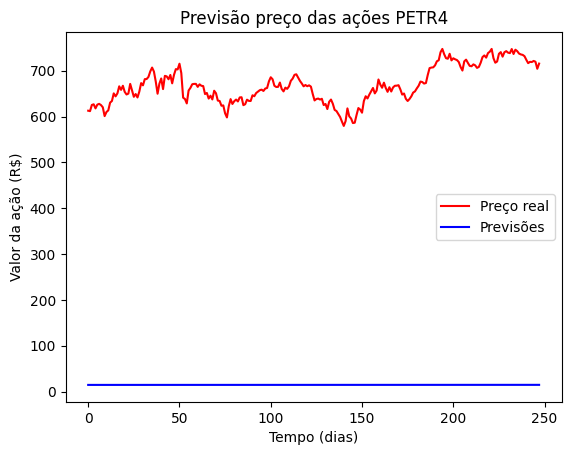

In [ ]:
#efetua as previsões
previsoes = regressor.predict(X_teste)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step


In [ ]:
print(previsoes.shape)


(248, 90, 1)


In [ ]:
# Seleciona o último valor previsto de cada sequência
previsoes_reshape = previsoes[:, -1, :]  # shape: (248, 1)

# Desnormaliza
previsoes_desnormalizadas = normalizador.inverse_transform(previsoes_reshape)


In [ ]:
previsoes_desnormalizadas = normalizador.inverse_transform(previsoes_reshape)


In [ ]:
preco_real_reshape = preco_real_teste
preco_real_desnormalizado = normalizador.inverse_transform(preco_real_reshape).flatten()

In [ ]:
print(previsoes_reshape[:5])


[[0.43294835]
 [0.43293622]
 [0.43289983]
 [0.43316114]
 [0.43338108]]


In [ ]:
#reconverte ("desnormaliza") os dados para R$
#previsoes = normalizador.inverse_transform(previsoes)

In [ ]:
print("Média previsões: R${:-f}".format(previsoes.mean()))
print("Média real: R${:.2f}".format(preco_real_teste.mean()))

Média previsões: R$0.434646
Média real: R$27.62


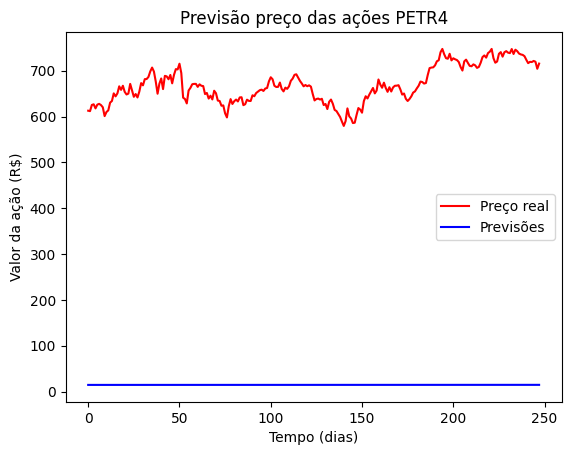

In [ ]:
plt.plot(preco_real_desnormalizado, color='red', label='Preço real')
plt.plot(previsoes_desnormalizadas, color='blue', label='Previsões')
plt.title('Previsão preço das ações PETR4')
plt.xlabel('Tempo (dias)')
plt.ylabel('Valor da ação (R$)')
plt.legend()
plt.show()